In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from datetime import date

conn = duckdb.connect('../ecommerce.db')

df = conn.execute("""
    SELECT
        customer_id,
        customer_name,
        city,
        acquisition_channel,
        signup_date,
        total_orders,
        completed_orders,
        total_revenue,
        avg_order_value,
        first_order_date,
        last_order_date
    FROM analytics.mart_customer_lifetime
    WHERE completed_orders > 0
""").df()

conn.close()

df['last_order_date'] = pd.to_datetime(df['last_order_date'])
df['first_order_date'] = pd.to_datetime(df['first_order_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

print(f"Customers with orders: {len(df)}")
df.head()

Customers with orders: 1901


,customer_id,customer_name,city,acquisition_channel,signup_date,total_orders,completed_orders,total_revenue,avg_order_value,first_order_date,last_order_date
0,C1174,Triveni Shere,Pune,organic,2024-05-17,6,2,16516.70,8258.35,2024-06-30,2024-06-30
1,C1401,Anamika Krishnan,Chennai,paid_search,2023-07-15,6,4,9485.61,2371.40,2023-10-06,2024-06-30
2,C0378,Reva Dalal,Kolkata,organic,2022-11-06,6,5,22845.69,4569.14,2023-06-24,2024-06-30
3,C1969,Lucky Rajan,Hyderabad,email,2022-02-25,2,2,5872.84,2936.42,2022-03-10,2023-04-23
4,C0473,Jai Sen,Kolkata,organic,2023-12-28,6,4,10696.83,2674.21,2023-12-31,2024-06-30


In [5]:
snapshot_date = pd.Timestamp('2024-07-01')

df['recency_days'] = (snapshot_date - df['last_order_date']).dt.days
df['frequency']    = df['completed_orders']
df['monetary']     = df['total_revenue']

def score(series, reverse=False):
    # use rank-based scoring which handles duplicates cleanly
    pct = series.rank(pct=True)
    if reverse:
        pct = 1 - pct
    return pd.cut(pct,
                  bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                  labels=[1, 2, 3, 4, 5],
                  include_lowest=True).astype(float)

df['r_score'] = score(df['recency_days'], reverse=True)
df['f_score'] = score(df['frequency'])
df['m_score'] = score(df['monetary'])

df['rfm_score'] = df['r_score'] + df['f_score'] + df['m_score']

print("RFM score distribution:")
print(df['rfm_score'].describe().round(2))

RFM score distribution:
count    1901.00
mean        9.09
std         2.96
min         3.00
25%         7.00
50%         9.00
75%        11.00
max        14.00
Name: rfm_score, dtype: float64


In [6]:
features = df[['r_score', 'f_score', 'm_score']].dropna()

scaler   = MinMaxScaler()
scaled   = scaler.fit_transform(features)

kmeans   = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[features.index, 'cluster'] = kmeans.fit_predict(scaled)

cluster_summary = df.groupby('cluster').agg(
    count         = ('customer_id', 'count'),
    avg_recency   = ('recency_days', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_revenue   = ('monetary', 'mean'),
    avg_rfm       = ('rfm_score', 'mean')
).round(1)

print(cluster_summary.sort_values('avg_rfm', ascending=False))

         count  avg_recency  avg_frequency  avg_revenue  avg_rfm
cluster                                                         
2.0        594          1.0            4.5      19785.3     12.5
0.0        304        165.5            4.0      18633.9      9.3
1.0        688          1.0            2.1       6692.7      8.1
3.0        315        203.5            1.7       5618.3      4.8


In [7]:
# Look at the cluster_summary output above to assign labels
# Highest avg_rfm = Champions, lowest = Lost
cluster_order = cluster_summary['avg_rfm'].sort_values(ascending=False).index.tolist()

label_map = {
    cluster_order[0]: 'Champions',
    cluster_order[1]: 'Loyal',
    cluster_order[2]: 'At Risk',
    cluster_order[3]: 'Lost',
}

df['segment'] = df['cluster'].map(label_map)

print("Segment counts:")
print(df['segment'].value_counts())
print()
print("Segment revenue summary:")
print(df.groupby('segment').agg(
    customers     = ('customer_id', 'count'),
    avg_revenue   = ('monetary', 'mean'),
    total_revenue = ('monetary', 'sum'),
    avg_orders    = ('frequency', 'mean')
).round(2).sort_values('avg_revenue', ascending=False))

Segment counts:
segment
At Risk      688
Champions    594
Lost         315
Loyal        304
Name: count, dtype: int64

Segment revenue summary:
           customers  avg_revenue  total_revenue  avg_orders
segment                                                     
Champions        594     19785.30    11752470.62        4.51
Loyal            304     18633.88     5664700.57        3.97
At Risk          688      6692.73     4604601.10        2.08
Lost             315      5618.27     1769755.05        1.70


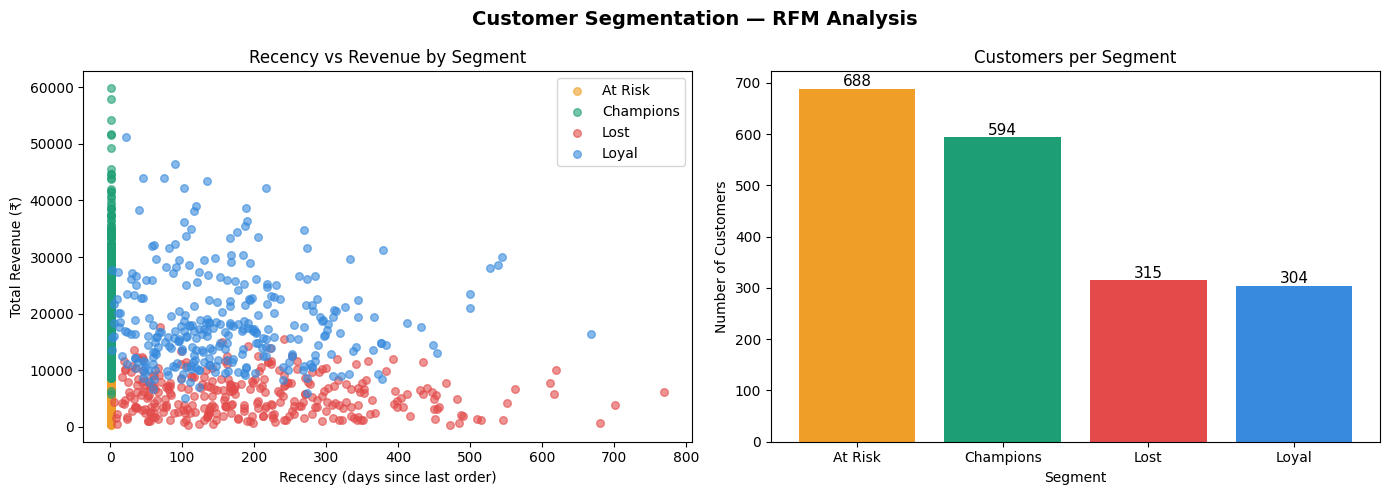

Chart saved to reports/rfm_segments.png


In [8]:
colors = {
    'Champions': '#1D9E75',
    'Loyal':     '#378ADD',
    'At Risk':   '#EF9F27',
    'Lost':      '#E24B4A',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segmentation — RFM Analysis', fontsize=14, fontweight='bold')

# Scatter: Recency vs Monetary
ax1 = axes[0]
for segment, group in df.groupby('segment'):
    ax1.scatter(
        group['recency_days'],
        group['monetary'],
        c=colors[segment],
        label=segment,
        alpha=0.6,
        s=30
    )
ax1.set_xlabel('Recency (days since last order)')
ax1.set_ylabel('Total Revenue (₹)')
ax1.set_title('Recency vs Revenue by Segment')
ax1.legend()

# Bar: Customer count per segment
ax2 = axes[1]
seg_counts = df['segment'].value_counts()
bars = ax2.bar(
    seg_counts.index,
    seg_counts.values,
    color=[colors[s] for s in seg_counts.index]
)
ax2.set_xlabel('Segment')
ax2.set_ylabel('Number of Customers')
ax2.set_title('Customers per Segment')
for bar, val in zip(bars, seg_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/rfm_segments.png")

In [9]:
conn = duckdb.connect('../ecommerce.db')

conn.execute("DROP TABLE IF EXISTS analytics.mart_customer_segments")
conn.execute("""
    CREATE TABLE analytics.mart_customer_segments AS
    SELECT
        customer_id,
        customer_name,
        city,
        acquisition_channel,
        segment,
        recency_days,
        frequency,
        monetary       AS total_revenue,
        r_score,
        f_score,
        m_score,
        rfm_score
    FROM df
""")

count = conn.execute("SELECT COUNT(*) FROM analytics.mart_customer_segments").fetchone()[0]
print(f"Saved {count} customers to analytics.mart_customer_segments")

print()
print("Segment breakdown in DB:")
print(conn.execute("""
    SELECT segment,
           COUNT(*) as customers,
           ROUND(AVG(total_revenue), 2) as avg_ltv
    FROM analytics.mart_customer_segments
    GROUP BY segment
    ORDER BY avg_ltv DESC
""").df().to_string(index=False))

conn.close()

Saved 1901 customers to analytics.mart_customer_segments

Segment breakdown in DB:
  segment  customers  avg_ltv
Champions        594 19785.30
    Loyal        304 18633.88
  At Risk        688  6692.73
     Lost        315  5618.27
